In [1]:
!pip install diffusers transformers accelerate torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 29.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
rm -rf ~/.cache/huggingface/hub

In [3]:
from diffusers import StableDiffusionPipeline
import torch
import warnings
warnings.filterwarnings("ignore")

# Carica il modello RealisticVision_V2
model_id = "emilianJR/RealisticVision_V2"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

# Sovrascrivi la funzione di controllo NSFW
def dummy_safety_checker(images, **kwargs):
    return images, [False] * len(images)  # Restituisce una lista di 'False' per ogni immagine

prompt = ("headshot portrait of a young woman, real life, shot on iPhone, realistic background, HD, HDR color, 4k, natural lighting, photography, Facebook"
"Instagram, Pexels, Flickr, Unsplash, 50mm, 85mm, #wow, AMAZING, epic details, epic, beautiful face, fantastic, cinematic, dramatic lighting")

negative_prompt = "cartoon, blurry, partial face, deformed, artistic filters, black and white, shadows, cropped head, unrealistic, painting, illustration"

# Genera l'immagine con il filtro NSFW disattivato
image = pipe(
    prompt,
    negative_prompt=negative_prompt,
    height=1024, width=768,
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

# Salva l'immagine
image.save("biometric_image_no_nsfw_filter.png")


model_index.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/520 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.58k [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

...

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--emilianJR--RealisticVision_V2/snapshots/07daf21e175bdb383f95f3a0aa71e717cbce68e4/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--emilianJR--RealisticVision_V2/snapshots/07daf21e175bdb383f95f3a0aa71e717cbce68e4/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--emilianJR--RealisticVision_V2/snapshots/07daf21e175bdb383f95f3a0aa71e717cbce68e4/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--emilianJR--RealisticVision_V2/snapshots/07daf21e175bdb383f95f3a0aa71e717cbce68e4/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

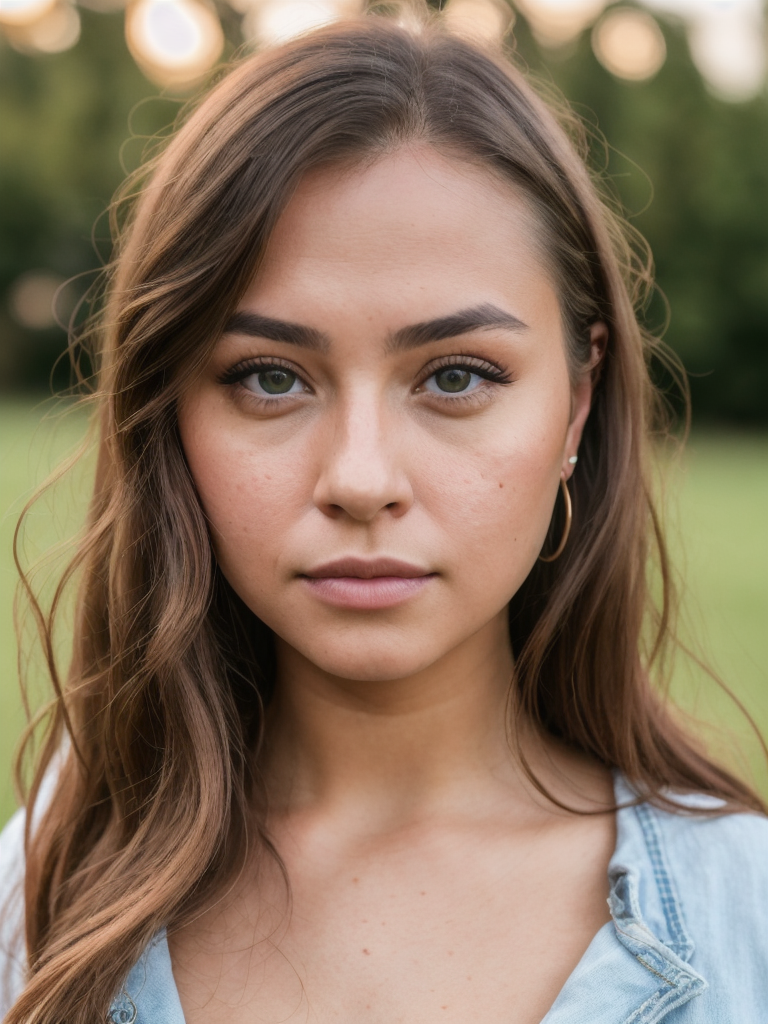

In [4]:
# Mostra l'immagine generata
from PIL import Image
img = Image.open("biometric_image_no_nsfw_filter.png")
display(img)